# 5 — The spectral gap, eigenvalue degeneracy, and a word on DQPTs

Notebook 2 ended with a warning: even with the validated VD2 MPO, the transverse contraction
**stops converging beyond a certain time**. Here we diagnose that by looking directly at the
spectrum of the spatial transfer matrix $\mathcal{E}$. Two leading eigenvalues approach each other
(a **closing gap**), which stalls the power method. We show that the naive fix — single-vector
deflation for the subleading eigenvalue — *fails* numerically, introduce the **block power method**
that solves it, and use the resulting clean spectrum to settle what the closing gap actually is.

Along the way we introduce **dynamical quantum phase transitions (DQPTs)** for the first time, since
a closing gap and a non-analytic Loschmidt rate are easily confused — and explain why, for our
quench *to* the critical point, there is in fact **no DQPT**.

## Diagnosing convergence: the subleading eigenvalue by deflation

The power method converges geometrically at a rate set by the **gap ratio**
$|\lambda_1|/|\lambda_0|$ between the two leading transfer-matrix eigenvalues: as it approaches $1$,
convergence grinds to a halt. The textbook way to measure $\lambda_1$ is **deflation** — run the
power method in the subspace orthogonal to the dominant eigenvector. For the non-Hermitian
$\mathcal{E}$ this means projecting out the dominant pair $(\langle L_0|, |R_0\rangle)$ at every
step using the *bilinear* (non-conjugating) overlap, and iterating a modified map.

The helpers below implement exactly this. They are kept local to this notebook because — as we are
about to see — this is the method that **does not work** at the interesting times.

In [1]:
include("src/thesislib.jl")
using LinearAlgebra

# Single-vector deflation for the subleading eigenvalue λ1 (the method that FAILS at the gap).
function gen_exc1_right(mpo::MPO, L0::MPS, R0::MPS, in_R::MPS; cutoff=1e-10)
    opsi = applyn(mpo, in_R; cutoff=cutoff)
    n = norm(opsi); n > 1e-25 && (opsi ./= n)
    add(opsi, -overlap_noconj(L0, opsi) * R0; cutoff=cutoff)   # project out the dominant mode
end
function gen_exc1_left(mpo_dag::MPO, L0::MPS, R0::MPS, in_L::MPS; cutoff=1e-10)
    opsi = applyn(mpo_dag, in_L; cutoff=cutoff)
    n = norm(opsi); n > 1e-25 && (opsi ./= n)
    add(opsi, -overlap_noconj(R0, opsi) * L0; cutoff=cutoff)
end

function compute_spectral_gap_LR(L0::MPS, R0::MPS, mpo::MPO; itermax=200, cutoff=1e-10)
    ov0 = overlap_noconj(L0, R0)
    (isnan(abs(ov0)) || abs(ov0) < 1e-25) && return (NaN+im*NaN, NaN+im*NaN, NaN)
    lam0 = expval_LR(L0, mpo, R0) / ov0
    mpo_dag = swapprime(dag(mpo), 0, 1)
    R1 = complex.(randomMPS(siteinds(R0), linkdims=4)); R1 ./= norm(R1); L1 = copy(R1)
    R1 = add(R1, -overlap_noconj(L0,R1)*R0; cutoff=cutoff); R1 ./= norm(R1)
    L1 = add(L1, -overlap_noconj(R0,L1)*L0; cutoff=cutoff); L1 ./= norm(L1)
    for _ in 1:itermax
        Ru = gen_exc1_right(mpo, L0, R0, R1; cutoff=cutoff); n=norm(Ru); n>1e-20 && (R1 = Ru/n)
        Lu = gen_exc1_left(mpo_dag, L0, R0, L1; cutoff=cutoff); n=norm(Lu); n>1e-20 && (L1 = Lu/n)
    end
    ov1 = overlap_noconj(L1, R1)
    lam1 = abs(ov1) < 1e-14 ? inner(R1,mpo,R1)/inner(R1,R1) : expval_LR(L1,mpo,R1)/ov1
    return lam0, lam1, abs(lam0) - abs(lam1)
end

compute_spectral_gap_LR (generic function with 1 method)

### Why deflation breaks down

Deflation divides by the dominant eigenvalue and relies on the bi-orthogonal pair
$(\langle L_1|, |R_1\rangle)$ staying well-separated from $(\langle L_0|, |R_0\rangle)$. Precisely at
the gap closing — where $|\lambda_1|\to|\lambda_0|$ — the residual after projection collapses to
(near) zero norm. Normalizing a zero-norm state produces `NaN`/`Inf`, which then crashes the
diagonalization inside `add`. In practice the method dies *exactly at the times we most want to
study* (the gap closing). This motivates a method that tracks several eigenvalues **simultaneously**
and never divides by a single dominant one.

## The block (subspace) power method

The fix is a two-sided **block power method** — an oblique Rayleigh–Ritz (Petrov–Galerkin) subspace
iteration that extracts the leading $k$ eigenvalues at once and stays well-behaved through a
degeneracy. It is implemented in the library as `block_transfer_eigs`. The algorithm keeps $k$ right
tMPS $|R_j\rangle$ and $k$ left tMPS $\langle L_i|$ (random complex seeds) and, each iteration:

1. applies the transfer matrix, $|AR_j\rangle=\mathcal{E}|R_j\rangle$ and
   $\langle AL_i|=\langle L_i|\mathcal{E}$ (the left map is the **pure transpose**
   `swapprime(mpo,0,1)` — the bilinear adjoint, no conjugation);
2. builds two dense $k\times k$ pencils from the *non-conjugating* overlap,
   $S_{ij}=\langle L_i|R_j\rangle$ and $M_{ij}=\langle L_i|\mathcal{E}|R_j\rangle$;
3. solves the Ritz problem as $W=\mathrm{pinv}(S)\,M$ then `eigen(W)` — *not* `eigen(M,S)`, whose
   generalized solver emits `Inf` when $S$ is near-singular at the degeneracy;
4. rotates the applied block by the Ritz vectors to de-mix the $k$ directions, and refreshes a
   collapsed direction (via Gram–Schmidt in the bilinear overlap) whenever $\mathrm{cond}(S)$ spikes.

Three implementation gotchas, all handled inside the library: `mps ./ scalar` broadcasts over all
$N$ tensors (scaling the norm by $\text{scalar}^N$) so we use scalar multiplication; MPS sums use
`+(...; alg="directsum")` then `truncate!` (the density-matrix `+` NaN-crashes on degenerate sums);
and the pseudo-inverse pencil above. The seed is **random**, never the structured `fw_tMPS`, which is
symmetry-special and converges to a subdominant eigenvalue.

In [ ]:
# Block PM sweep over T — crash-safe, caches per T to results/data/.
# Cached results (p=0.1: T=0.5..5.5, p=0: T=0.5..7.0) load instantly; new T are computed on demand.
p = 0.1; lambda = 1.0; dt = 0.1; maxdim = 256; cutoff = 1e-12
T_grid = collect(0.5:0.5:8.0); k_block = 4
cachefile = "results/data/block_pm_alcaraz_p$(p).jld2"

done = crashsafe_sweep(T_grid; cachefile=cachefile) do T
    mpo, scaffold = build_alcaraz_tmpo(T; p=p, lambda=lambda, dt=dt)
    theta, L, R, info = block_transfer_eigs(mpo, scaffold; k=k_block, maxdim=maxdim,
                                            cutoff=cutoff, itermax=800, eps_conv=1e-6, n_track=2)
    (theta=collect(theta), niters=info[:niters], reason=string(info[:reason]), condS=info[:condS])
end

@printf("%-6s %-10s %-10s %-12s %-8s %s\n","T","|θ₀|","|θ₁|","gap_ratio","niters","reason")
for T in sort(collect(keys(done)))
    r = done[T]; haskey(r,:error) && continue
    th = r.theta; gr = abs(th[2])/max(abs(th[1]),1e-30)
    @printf("%-6.1f %-10.5f %-10.5f %-12.5f %-8d %s\n", T, abs(th[1]), abs(th[2]), gr, r.niters, r.reason)
end

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=349|"S=1/2,Site") <-> (dim=2|id=349|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=421|"Link,l=1") <-> (dim=7|id=622|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=889|"S=1/2,Site") <-> (dim=2|id=889|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93


In [ ]:
# 3-panel spectral-gap figure (reads the cached sweep; saves to results/imgs/).
Ts=Float64[]; a0=Float64[]; a1=Float64[]; gr=Float64[]; ar0=Float64[]; ar1=Float64[]
for T in sort(collect(keys(done)))
    r = done[T]; haskey(r,:error) && continue
    th = r.theta; any(isnan,abs.(th)) && continue
    push!(Ts,T); push!(a0,abs(th[1])); push!(a1,abs(th[2]))
    push!(gr,abs(th[2])/max(abs(th[1]),1e-30)); push!(ar0,angle(th[1])); push!(ar1,angle(th[2]))
end
p1 = plot(Ts,a0; label="|λ₀|", marker=:circle, lw=1.5, color=:black, xlabel="T", ylabel="|λ|", title="Leading eigenvalues")
plot!(p1, Ts, a1; label="|λ₁|", marker=:circle, lw=1.5, color=:red); hline!(p1,[1.0]; ls=:dash, color=:gray, label="")
p2 = plot(Ts, gr; label="", marker=:circle, lw=1.5, color=:purple, xlabel="T", ylabel="|λ₁|/|λ₀|", title="Gap ratio → 1")
hline!(p2,[1.0]; ls=:dash, color=:gray, label="")
p3 = plot(Ts, ar0; label="arg λ₀", marker=:circle, lw=1.5, color=:black, xlabel="T", ylabel="arg(λ)", title="Phases (locked ~π apart)")
plot!(p3, Ts, ar1; label="arg λ₁", marker=:circle, lw=1.5, color=:red)
plt = plot(p1,p2,p3; layout=(1,3), size=(1500,460), margin=5Plots.mm,
           plot_title="Alcaraz block-PM spectral gap (p=$p, λ=$lambda, dt=$dt)")
mkpath("results/imgs"); savefig(plt, "results/imgs/block_pm_alcaraz_p$(p).png"); plt

### What the gap closing is (and is not)

The block method converges cleanly where deflation died, and the picture is unambiguous: the
leading modulus is essentially **flat, $|\lambda_0|\approx0.895$** (no cusp, no value above $1$),
while the gap ratio rises **monotonically toward $1$** as $T$ grows and the two leading phases stay
locked roughly $\pi$ apart.

A closing gap with a flat leading modulus is the **entanglement barrier** in spectral form: it is
the eigenvalue signature of the (logarithmically) growing temporal entropy, exactly the regime
Carignano–Tagliacozzo associate with a quench to a critical point. It is *not* a phase transition.
The earlier appearance of $|\lambda_0|>1$ at $T\approx6$ in single-vector runs was a
non-convergence artifact, not physics — the block method removes it.

Comparing $p=0$ (integrable Ising) with $p=0.1$ (Alcaraz) below shows the phenomenon is
**qualitatively the same** at both — a smoothly closing gap, no DQPT — so the barrier is not
*created* by the NNN coupling. But it is not quantitatively identical: **the gap closes faster as
$p$ grows**, i.e. the barrier sets in at *earlier* $T$. This is the natural reading — stronger NNN
frustration scrambles the state more quickly — and it is exactly why the single-vector entropy
profiles of notebook 3 broke down sooner for larger $p$.

![p=0 vs p=0.1 spectral gap](results/imgs/block_pm_ising_vs_alcaraz.png)

In [ ]:
# p=0 (Ising) vs p=0.1 (Alcaraz): same entanglement barrier, but it closes FASTER at larger p.
d0 = load("results/data/block_pm_alcaraz_p0.0.jld2", "done")
d1 = load("results/data/block_pm_alcaraz_p0.1.jld2", "done")
gapratio(d) = (Ts=sort([T for T in keys(d) if !haskey(d[T],:error)]);
          (Ts, [abs(d[T].theta[2])/max(abs(d[T].theta[1]),1e-30) for T in Ts]))
T0,gr0 = gapratio(d0); T1,gr1 = gapratio(d1)
plot(T0, gr0; label="p=0 (Ising)", marker=:circle, lw=2, color=:blue, xlabel="T",
     ylabel="gap ratio |λ₁|/|λ₀|", framestyle=:box, grid=true, legend=:bottomright,
     title="Entanglement barrier closes faster at larger p")
plot!(T1, gr1; label="p=0.1 (Alcaraz)", marker=:square, lw=2, color=:red)
hline!([1.0]; ls=:dash, color=:gray, label="gap closed")
# (Re-run the block-PM sweep with p=0.5 to add a third, even-faster-closing curve.)

## A word on dynamical quantum phase transitions (DQPTs)

Because a closing gap and a non-analytic Loschmidt rate look superficially similar, we pause to
introduce DQPTs properly. The Loschmidt amplitude $\mathcal{L}(t)=\langle\Psi_0|e^{-iHt}|\Psi_0\rangle$
is a boundary partition function with complex "inverse temperature" $it$. Its **rate function**
$\ell(t)=-\tfrac1N\log|\mathcal{L}(t)|^2$ can develop **non-analytic kinks** at sharp times $t_n^*$
when Fisher zeros of the partition function cross the time axis. These kinks are DQPTs (Heyl et al.,
2013).

For the transverse-field Ising model the DQPT condition is exact and analytic: a quench from $g_0$
to $g_1$ produces kinks at $t_n^* = (n+\tfrac12)\,\pi/\varepsilon_{k^*}(g_1)$ **only if the quench
crosses the critical point** $g_c=1$, where the critical mode satisfies $\cos k^* = (1+g_0g_1)/(g_0+g_1)$
and $\varepsilon_k(g)=2\sqrt{1+g^2-2g\cos k}$. We can compute the free-fermion rate in closed form,
so this needs no heavy simulation.

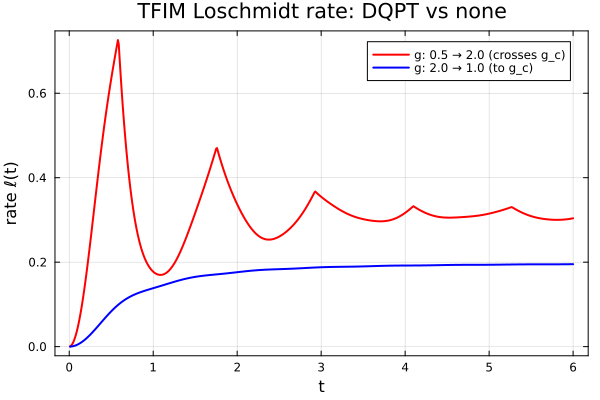

In [3]:
# Exact free-fermion TFIM Loschmidt rate (Heyl et al. 2013) — instant, no MPS.
εk(k,g)  = 2*sqrt(1 + g^2 - 2g*cos(k))
θk(k,g)  = 0.5*atan(sin(k), g - cos(k))                # Bogoliubov angle
function tfim_rate(ts, g0, g1; nk=4000)
    ks = range(0, pi, length=nk); dk = step(ks)
    [ -(1/pi)*sum(log(max(1 - sin(2*(θk(k,g0)-θk(k,g1)))^2 * sin(εk(k,g1)*t)^2, 1e-300)) for k in ks)*dk
      for t in ts ]
end

ts = range(0.01, 6.0, length=600)
cross  = tfim_rate(ts, 0.5, 2.0)   # quench ACROSS g_c=1  → DQPT kinks
tocrit = tfim_rate(ts, 2.0, 1.0)   # quench TO g_c=1       → no finite-time DQPT
plot(ts, cross;  label="g: 0.5 → 2.0 (crosses g_c)", lw=2, color=:red, xlabel="t",
     ylabel="rate ℓ(t)", framestyle=:box, grid=true, title="TFIM Loschmidt rate: DQPT vs none")
plot!(ts, tocrit; label="g: 2.0 → 1.0 (to g_c)", lw=2, color=:blue)

### Why our quench has no DQPT

The red curve shows the textbook DQPT: sharp kinks at the predicted $t_n^*$ for a quench that
**crosses** the critical point. The blue curve — a quench **to** the critical point — is smooth: as
$g_1\to g_c=1$ the critical mode moves to $k^*\to0$, where $\varepsilon_{k^*}\to0$ and the first
DQPT time $t_1^*\to\infty$. The Fisher zero becomes *marginal* and never crosses the time axis at
finite time.

This is exactly our situation. We always quench the ANNNI-type model **to** its critical point
$\lambda=1$ — never across it — so **no DQPT occurs at finite time**, for $p=0$ or $p>0$. The
closing transfer-matrix gap diagnosed above is therefore the universal **entanglement barrier**, not
a dynamical phase transition. We record the DQPT machinery here for completeness; it does not feature
in the results of notebooks 6–7.

With a converged, correctly-interpreted spectrum in hand, we can finally extract the *temporal*
central charge — first validating the whole pipeline on the integrable Ising chain (notebook 6),
then stress-testing it on the Alcaraz model (notebook 7).